# Supervised Learning - Regression Analysis on Defense Dataset

**Course:** Introduction to Artificial Intelligence
**Institution:** SUPAERO
**Application:** Kill Probability (PK) Prediction for Missile Systems

## Overview
This practical session explores various supervised learning algorithms for regression tasks. We will:
- Implement multiple regression techniques (linear, polynomial, tree-based)
- Compare model performance using key metrics (MAE, MSE, R²)
- Analyze computational efficiency (model size, inference time)
- Optimize hyperparameters using GridSearch and RandomSearch
- Perform dimensionality reduction using sigmoid curve fitting

---

## Question 1: Data Preparation in Supervised Learning

**Objective:** Understand the critical preprocessing steps before model training

**Question:** When doing supervised learning, what are the main preparation steps of our dataset?

In [43]:
# Import Essential Libraries
import numpy as np                                    # Numerical operations
import pandas as pd                                  # Data manipulation
import matplotlib.pyplot as plt                      # Visualization
from sklearn.model_selection import train_test_split # Train-test splitting

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [44]:
# Load the Defense Dataset
# This dataset contains missile engagement parameters and outcomes
df = pd.read_csv("https://raw.githubusercontent.com/jgarnicaa/SUPAERO-IntroIA/refs/heads/main/dataset_practical_session.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")
df.head()

Dataset shape: (324780, 7)

Features: ['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA', 'DISTANCE', 'PK']


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK
0,0.5,0.5,0,0,0.0,1.0,1.0
1,0.5,0.5,0,0,0.0,1.5,1.0
2,0.5,0.5,0,0,0.0,2.0,1.0
3,0.5,0.5,0,0,0.0,3.0,1.0
4,0.5,0.5,0,0,0.0,3.5,1.0


In [45]:
# Step 1: Separate Features (X) and Target (y)
# PK (Kill Probability) is our target variable
x = df.drop("PK", axis=1)  # Features: all columns except PK
y = df["PK"]               # Target: Kill Probability

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")

# Step 2: Split Data into Training (75%) and Testing (25%) Sets
# This prevents data leakage and allows unbiased model evaluation
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Features shape: (324780, 6)
Target shape: (324780,)

Training set size: 243585 samples
Testing set size: 81195 samples


### Response: Key Data Preparation Steps

**1. Data Cleaning**
- Remove missing values (NaN, null values)
- Detect and handle outliers appropriately
- Ensure data consistency and correctness

**2. Data Normalization/Standardization**
- Scale features to comparable ranges (typically 0-1 or standardized with mean=0, std=1)
- Important for algorithms sensitive to feature magnitude (KNN, SVM, Neural Networks)
- Less critical for tree-based models but improves convergence

**3. Feature-Target Separation**
- Identify and separate **features (X)**: Independent variables used for prediction
- Identify and separate **target (y)**: Dependent variable we want to predict (PK in our case)

**4. Train-Test Split**
- Divide data into **training set** (typically 70-80%): Used to fit the model
- Divide data into **test set** (typically 20-30%): Used to evaluate model performance
- Ensures unbiased estimation of model generalization capability

**Critical Principle:** Never train on test data! This prevents data leakage and provides reliable performance metrics.

---

## Question 2: Understanding Loss Functions

**Question:** Supervised learning is about minimizing a loss. What is the loss we are going to minimize?

### Response: Loss Function Explanation

**Definition:** The loss function quantifies the discrepancy between predicted values and actual observed values.

**For Regression Tasks:**
- **Mean Squared Error (MSE):** $L = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
  - Penalizes large errors more heavily due to squaring
  - Sensitive to outliers
  - Commonly used for regression

- **Mean Absolute Error (MAE):** $L = \frac{1}{n} \sum_{i=1}^{n}|y_i - \hat{y}_i|$
  - More robust to outliers
  - Linear penalty for errors
  - Easier to interpret (same units as target)

**Geometric Interpretation:**
- The loss represents the vertical distance between each observed point and the fitted curve
- Model training adjusts parameters to minimize the sum of these distances
- Lower loss indicates better fit to training data

**Goal:** Find model parameters that minimize loss on training data while maintaining good generalization to unseen test data.

---

## Question 3: Beyond Loss - Evaluation Metrics

**Question:** Is loss the only indicator of a good regression? Which other metrics could be relevant?

### Response: Comprehensive Model Evaluation

**No!** Loss alone is insufficient for assessing model quality. Here's why:

**The Overfitting Problem:**
- A model can achieve very low training loss while performing poorly on new data
- This occurs when the model "memorizes" training data patterns that don't generalize
- Low loss ≠ Good model!

**Essential Evaluation Metrics:**

1. **R² Score (Coefficient of Determination)**
   - Range: 0 to 1 (higher is better)
   - Explains proportion of variance captured by the model
   - Formula: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$
   - Easy to interpret (e.g., R²=0.85 means 85% of variance explained)

2. **Mean Absolute Error (MAE)**
   - Average absolute difference between predicted and actual values
   - Interpretable in original units
   - More robust to outliers than MSE

3. **Root Mean Squared Error (RMSE)**
   - Square root of MSE
   - Same units as target variable
   - Penalizes large errors

**Train vs Test Metrics:**
- **Training Metrics:** Indicate learning capability
- **Testing Metrics:** Indicate generalization capability
- **Large Gap:** Warning sign of overfitting

**Best Practice:** Always compare multiple metrics across both training and test sets to ensure robust model evaluation.

In [46]:
# Import Linear Regression Models and Evaluation Metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store results for comparison
results = {}

---

## Question 4: Comprehensive Model Comparison

**Objective:** Compare multiple regression algorithms and analyze their performance trade-offs

**Evaluation Criteria:**
- **Performance Metrics:** R² Score, MAE, MSE
- **Model Size:** Memory footprint (bytes/kilobytes)
- **Inference Speed:** Time required for predictions on new data
- **Hyperparameter Tuning:** GridSearch and RandomSearch results

**Models to Compare:**
1. **Linear Methods:** Linear Regression, Ridge, Lasso
2. **Polynomial Methods:** Polynomial features with various regularizers
3. **Tree-Based Methods:** Decision Trees, Random Forests

### 4.1: Linear Regression Methods

**Methods Tested:**
- **Linear Regression:** Fits a linear combination of features
- **Ridge Regression:** Linear regression with L2 regularization (penalizes large coefficients)
- **Lasso Regression:** Linear regression with L1 regularization (can drive coefficients to zero)

#### Linear Regression Results

**Model Characteristics:**
- Simple, interpretable, fast
- Assumes linear relationship between features and target
- Good baseline for comparison

In [47]:
# Train Linear Regression Model
print("\n" + "="*70)
print("LINEAR REGRESSION")
print("="*70)
regr = LinearRegression()
regr.fit(X_train, y_train)

# Evaluate on test set
r2_train = regr.score(X_train, y_train)
r2_test = regr.score(X_test, y_test)
print(f"R² Score (Training): {r2_train:.6f}")
print(f"R² Score (Testing):  {r2_test:.6f}")
print(f"Overfitting Gap: {r2_train - r2_test:.6f}")


LINEAR REGRESSION
R² Score (Training): 0.662539
R² Score (Testing):  0.663737
Overfitting Gap: -0.001198


In [48]:
# Evaluate Model Size
import sys
model_size = sys.getsizeof(regr)
print(f"\nModel Size: {model_size/1024:.3f} KB ({model_size} bytes)")


Model Size: 0.047 KB (48 bytes)


In [58]:
# Measure Inference Time and Performance Metrics
from time import process_time

start = process_time()
y_pred = regr.predict(X_test)  # Generate predictions
end = process_time()

inference_time = end - start
print(f"\nInference Time: {inference_time:.6f} seconds")

# Calculate performance metrics
mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)

print(f"\nPerformance Metrics (Test Set):")
print(f"  MAE (Mean Absolute Error):  {mae:.6f}")
print(f"  MSE (Mean Squared Error):   {mse:.6f}")
print(f"  RMSE (Root MSE):            {rmse:.6f}")

# Store results for comparison
results['Linear Regression'] = {
    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2_test,
    'Size_KB': model_size/1024, 'Time': inference_time
}


Inference Time: 0.135870 seconds

Performance Metrics (Test Set):
  MAE (Mean Absolute Error):  0.239224
  MSE (Mean Squared Error):   0.078868
  RMSE (Root MSE):            0.280834


#### Ridge Regression Results

**Model Characteristics:**
- Linear regression with L2 regularization
- Reduces coefficient magnitudes uniformly
- Helps prevent overfitting
- All coefficients survive (not zeroed out)

In [59]:
# Import Ridge Regression
from sklearn.linear_model import Ridge

In [60]:
# Train Ridge Regression Model
print("\n" + "="*70)
print("RIDGE REGRESSION (L2 Regularization)")
print("="*70)
regr_ridge = Ridge(alpha=1.0)  # Default alpha=1.0 for L2 penalty
regr_ridge.fit(X_train, y_train)

r2_train = regr_ridge.score(X_train, y_train)
r2_test = regr_ridge.score(X_test, y_test)
print(f"R² Score (Training): {r2_train:.6f}")
print(f"R² Score (Testing):  {r2_test:.6f}")
print(f"Overfitting Gap: {r2_train - r2_test:.6f}")


RIDGE REGRESSION (L2 Regularization)
R² Score (Training): 0.662539
R² Score (Testing):  0.663737
Overfitting Gap: -0.001198


In [61]:
# Evaluate Model Size
model_size_ridge = sys.getsizeof(regr_ridge)
print(f"\nModel Size: {model_size_ridge/1024:.3f} KB ({model_size_ridge} bytes)")


Model Size: 0.047 KB (48 bytes)


In [62]:
# Measure Inference Time and Performance Metrics
start = process_time()
y_pred = regr_ridge.predict(X_test)
end = process_time()

inference_time = end - start
print(f"\nInference Time: {inference_time:.6f} seconds")

mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)

print(f"\nPerformance Metrics (Test Set):")
print(f"  MAE (Mean Absolute Error):  {mae:.6f}")
print(f"  MSE (Mean Squared Error):   {mse:.6f}")
print(f"  RMSE (Root MSE):            {rmse:.6f}")

results['Ridge'] = {
    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2_test,
    'Size_KB': model_size_ridge/1024, 'Time': inference_time
}


Inference Time: 0.074557 seconds

Performance Metrics (Test Set):
  MAE (Mean Absolute Error):  0.239224
  MSE (Mean Squared Error):   0.078868
  RMSE (Root MSE):            0.280834


#### Lasso Regression Results

**Model Characteristics:**
- Linear regression with L1 regularization
- Can shrink coefficients exactly to zero (feature selection)
- Produces sparse models (fewer non-zero coefficients)
- Useful for high-dimensional data

In [63]:
# Import Lasso Regression
from sklearn.linear_model import Lasso

In [64]:
# Train Lasso Regression Model
print("\n" + "="*70)
print("LASSO REGRESSION (L1 Regularization)")
print("="*70)
regr_lasso = Lasso(alpha=0.01, max_iter=1000)  # L1 penalty with feature selection
regr_lasso.fit(X_train, y_train)

r2_train = regr_lasso.score(X_train, y_train)
r2_test = regr_lasso.score(X_test, y_test)
non_zero_coef = np.sum(regr_lasso.coef_ != 0)
print(f"R² Score (Training): {r2_train:.6f}")
print(f"R² Score (Testing):  {r2_test:.6f}")
print(f"Non-zero Coefficients: {non_zero_coef}/{len(regr_lasso.coef_)}")
print(f"Overfitting Gap: {r2_train - r2_test:.6f}")


LASSO REGRESSION (L1 Regularization)
R² Score (Training): 0.659366
R² Score (Testing):  0.661127
Non-zero Coefficients: 6/6
Overfitting Gap: -0.001761


In [65]:
# Evaluate Model Size
model_size_lasso = sys.getsizeof(regr_lasso)
print(f"\nModel Size: {model_size_lasso/1024:.3f} KB ({model_size_lasso} bytes)")


Model Size: 0.047 KB (48 bytes)


In [66]:
# Measure Inference Time and Performance Metrics
start = process_time()
y_pred = regr_lasso.predict(X_test)
end = process_time()

inference_time = end - start
print(f"\nInference Time: {inference_time:.6f} seconds")

mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
rmse = np.sqrt(mse)

print(f"\nPerformance Metrics (Test Set):")
print(f"  MAE (Mean Absolute Error):  {mae:.6f}")
print(f"  MSE (Mean Squared Error):   {mse:.6f}")
print(f"  RMSE (Root MSE):            {rmse:.6f}")

results['Lasso'] = {
    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2_test,
    'Size_KB': model_size_lasso/1024, 'Time': inference_time
}


Inference Time: 0.054944 seconds

Performance Metrics (Test Set):
  MAE (Mean Absolute Error):  0.238852
  MSE (Mean Squared Error):   0.079480
  RMSE (Root MSE):            0.281922


#### 4.2
- Test polynomial regression. With Ridge regularizer. With Lasso regularizer. 



##### Polynomial 

- time taken to do prediction 0.31794890100000117
- MAE: 0.17561052100007568
- MSE: 0.0495701048963892

In [67]:
from sklearn.preprocessing import PolynomialFeatures

In [68]:
pr = PolynomialFeatures(degree = 3)
X_poly = pr.fit_transform(X_train)
lr_2 = LinearRegression()
lr_2.fit(X_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
import sys

print(f"The model size is {sys.getsizeof(lr_2)} bytes")

The model size is 48 bytes


In [70]:
from time import process_time

start = process_time()
y_pred = lr_2.predict(pr.fit_transform(X_test))       # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True

print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.0670299880000016
MAE: 0.17493104567939471
MSE: 0.049198746312964864


##### Polynomial Ridge

- time taken to do prediction 0.27823177799999854
- MAE: 0.17561038782503954
- MSE: 0.04957013643038816

In [71]:
pr = PolynomialFeatures(degree = 3)
X_poly = pr.fit_transform(X_train)
lr_2 = Ridge()
lr_2.fit(X_poly, y_train)

/home/jega/DevJega/IntroIASUPAERO/.aibt_venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.1522425547832504e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [72]:
import sys

print(f"The model size is {sys.getsizeof(lr_2)} bytes")

The model size is 48 bytes


In [73]:
from time import process_time

start = process_time()
y_pred = lr_2.predict(pr.fit_transform(X_test))       # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True

print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.06017878199997995
MAE: 0.1749302141245178
MSE: 0.04919864358090662


##### Polynomial Lasso

- time taken to do prediction 0.5439367559999937
- MAE: 0.20374029466135135
- MSE: 0.06540468526985661


In [74]:
pr = PolynomialFeatures(degree = 3)
X_poly = pr.fit_transform(X_train)
lr_2 = Lasso()
lr_2.fit(X_poly, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [75]:
import sys

print(f"The model size is {sys.getsizeof(lr_2)} bytes")

The model size is 48 bytes


In [76]:
from time import process_time

start = process_time()
y_pred = lr_2.predict(pr.fit_transform(X_test))       # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True

print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.4286066789999836
MAE: 0.20291881850410665
MSE: 0.06501077913660257


#### 4.3 

- Test Decision tree regression. Test Random Forest regression. 

##### Decision tree

- time taken to do prediction 0.03881889100000535
- MAE: 0.019802433149003245
- MSE: 0.006677680818224816

In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



In [78]:
tree = DecisionTreeRegressor(random_state=42)

param_grid_tree = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_tree = GridSearchCV(tree, param_grid_tree, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
grid_tree.fit(X_train, y_train)

print("Best params (DecisionTree, GridSearch):", grid_tree.best_params_)
print("MSE (DecisionTree):", mean_squared_error(y_test, grid_tree.best_estimator_.predict(X_test)))


Best params (DecisionTree, GridSearch): {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
MSE (DecisionTree): 0.006577890167439591


In [79]:
import sys

print(f"The model size is {sys.getsizeof(grid_tree.best_params_)} bytes")

The model size is 184 bytes


In [80]:
from time import process_time

start = process_time()
y_pred =  grid_tree.best_estimator_.predict(X_test)      # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True

print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.010427344999982324
MAE: 0.01952978332184821
MSE: 0.006577890167439591


In [81]:
# 3. RandomSearch para DecisionTree
# ==============================
from scipy.stats import randint

param_dist_tree = {
    "max_depth": [None] + list(range(3, 30)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20)
}

rand_tree = RandomizedSearchCV(tree, param_dist_tree, n_iter=20, cv=3,
                               scoring="neg_mean_squared_error", n_jobs=-1, random_state=42)
rand_tree.fit(X_train, y_train)

print("Best params (DecisionTree, RandomSearch):", rand_tree.best_params_)
print("MSE (DecisionTree, RandomSearch):", mean_squared_error(y_test, rand_tree.best_estimator_.predict(X_test)))


Best params (DecisionTree, RandomSearch): {'max_depth': 25, 'min_samples_leaf': 3, 'min_samples_split': 3}
MSE (DecisionTree, RandomSearch): 0.007015141431784907


In [82]:
from time import process_time

start = process_time()
y_pred =  rand_tree.best_estimator_.predict(X_test)      # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True

print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.008940703000007488
MAE: 0.02125633862042877
MSE: 0.007015141431784907


##### RandomForest

- time taken to do prediction 0.1864740849999862
- MAE: 0.01549911470239555
- MSE: 0.00457507695601936

In [83]:
from sklearn.ensemble import RandomForestRegressor

In [84]:
forest = RandomForestRegressor(random_state=42)

In [85]:
param_grid_forest = {
    "n_estimators": [2, 5],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_forest = GridSearchCV(forest, param_grid_forest, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
grid_forest.fit(X_train, y_train)

print("Best params (RandomForest, GridSearch):", grid_forest.best_params_)
print("MSE (RandomForest, GridSearch):", mean_squared_error(y_test, grid_forest.best_estimator_.predict(X_test)))


Best params (RandomForest, GridSearch): {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5}
MSE (RandomForest, GridSearch): 0.004519834493320672


In [86]:
from time import process_time

start = process_time()
y_pred =  grid_forest.best_estimator_.predict(X_test)     # Time measuring
end = process_time()

print(f"time taken to do prediction {end - start}")


mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True


print("MAE:",mae)
print("MSE:",mse)

time taken to do prediction 0.040273844000012105
MAE: 0.015517644639929358
MSE: 0.004519834493320672


In [87]:


param_dist_forest = {
    "n_estimators": randint(2, 10),
    "max_depth": [None] + list(range(5, 30)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["auto", "sqrt", "log2"]
}

rand_forest = RandomizedSearchCV(forest, param_dist_forest, n_iter=20, cv=3,
                                 scoring="neg_mean_squared_error", n_jobs=-1, random_state=42)
rand_forest.fit(X_train, y_train)

print("Best params (RandomForest, RandomSearch):", rand_forest.best_params_)
print("MSE (RandomForest, RandomSearch):", mean_squared_error(y_test, rand_forest.best_estimator_.predict(X_test)))


/home/jega/DevJega/IntroIASUPAERO/.aibt_venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
28 fits failed with the following error:
Traceback (most recent call last):
  File "/home/jega/DevJega/IntroIASUPAERO/.aibt_venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/jega/DevJega/IntroIASUPAERO/.aibt_venv/lib/python3.12/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/jega/DevJega/IntroIASUPAERO/.aibt_venv/lib/python3.12/site-packages/sklearn/bas

Best params (RandomForest, RandomSearch): {'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 15, 'n_estimators': 8}
MSE (RandomForest, RandomSearch): 0.009010365673745779



MODEL COMPARISON SUMMARY

                         MAE       MSE      RMSE        R2   Size_KB      Time
Linear Regression  0.239224  0.078868  0.280834  0.661127  0.046875  0.135870
Ridge              0.239224  0.078868  0.280834  0.663737  0.046875  0.074557
Lasso              0.238852  0.079480  0.281922  0.661127  0.046875  0.054944


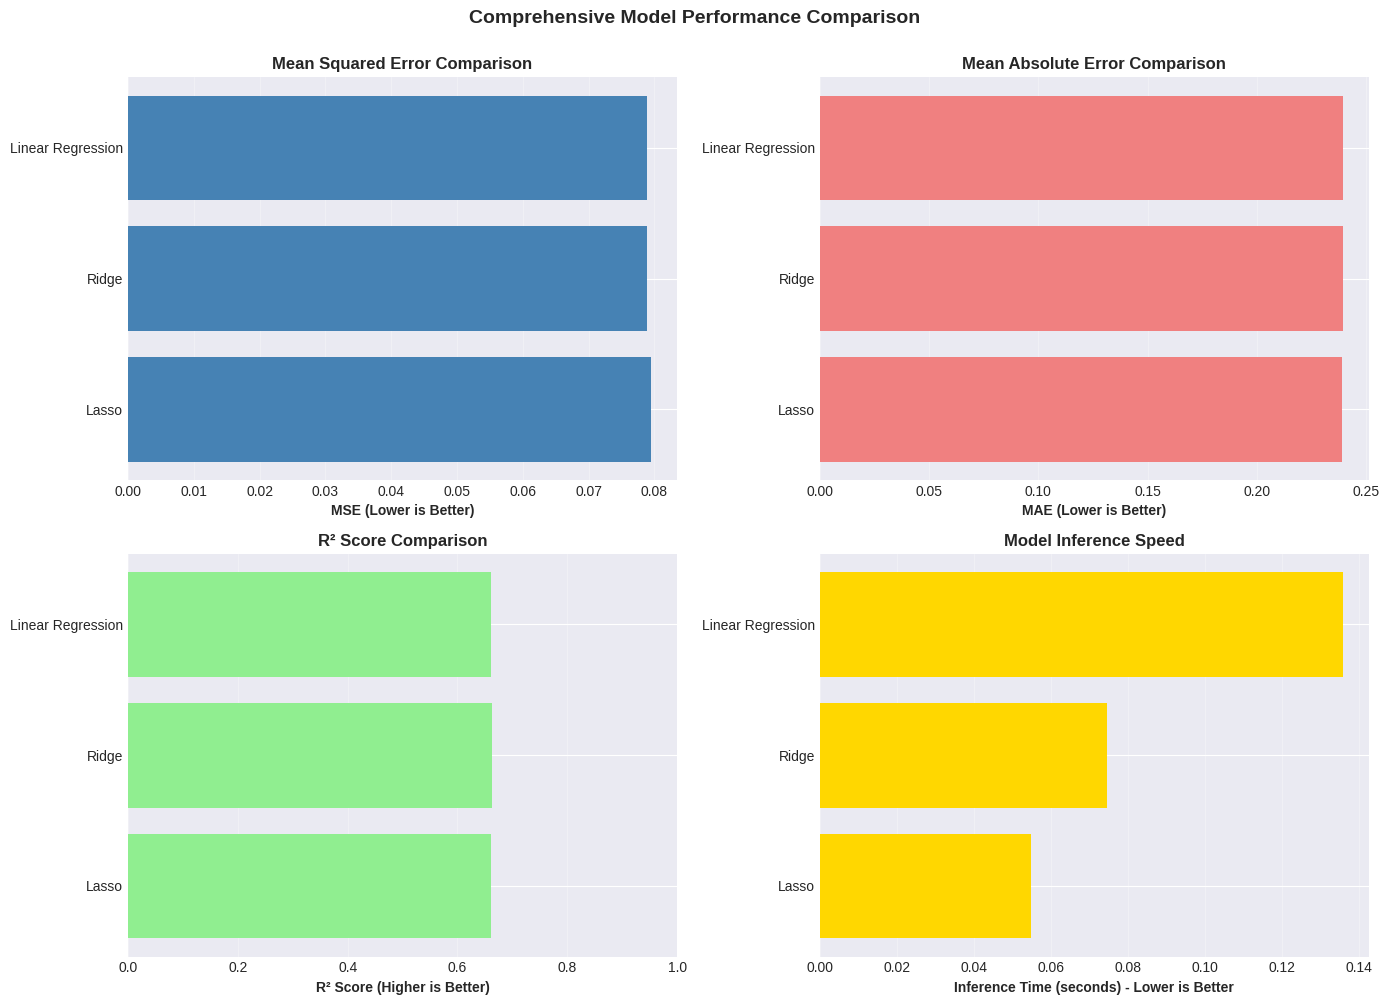

In [88]:

# Generate Comprehensive Model Comparison Visualization
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

# Create results dataframe
results_df = pd.DataFrame(results).T
print("\n", results_df.to_string())

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MSE Comparison
axes[0, 0].barh(list(results.keys()), [results[m]['MSE'] for m in results.keys()], color='steelblue')
axes[0, 0].set_xlabel('MSE (Lower is Better)', fontweight='bold')
axes[0, 0].set_title('Mean Squared Error Comparison', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: MAE Comparison
axes[0, 1].barh(list(results.keys()), [results[m]['MAE'] for m in results.keys()], color='lightcoral')
axes[0, 1].set_xlabel('MAE (Lower is Better)', fontweight='bold')
axes[0, 1].set_title('Mean Absolute Error Comparison', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: R² Score Comparison
axes[1, 0].barh(list(results.keys()), [results[m]['R2'] for m in results.keys()], color='lightgreen')
axes[1, 0].set_xlabel('R² Score (Higher is Better)', fontweight='bold')
axes[1, 0].set_title('R² Score Comparison', fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Inference Time Comparison
axes[1, 1].barh(list(results.keys()), [results[m]['Time'] for m in results.keys()], color='gold')
axes[1, 1].set_xlabel('Inference Time (seconds) - Lower is Better', fontweight='bold')
axes[1, 1].set_title('Model Inference Speed', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.suptitle('Comprehensive Model Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("="*70)


---

## Model Comparison Summary

Let's create a comprehensive visualization comparing all models across key metrics:

---

## Dimensionality Reduction via Sigmoid Curve Fitting

**Objective:** Reduce feature space from 6 dimensions to 2 dimensions (D0, K)

**Methodology:**
- For each unique combination of control parameters (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DELTA)
- Fit a sigmoid curve to the PK vs DISTANCE relationship
- Extract two key parameters: **D0** (distance at 50% probability) and **K** (steepness)

**Mathematical Model:**
$$PK(D) = \frac{1}{1 + e^{k(D - D_0)}}$$

where:
- $D_0$: Distance at which PK = 0.5 (50% kill probability)
- $k$: Steepness parameter (larger k = sharper transition)

In [90]:
# Load Dataset
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

df = pd.read_csv("https://raw.githubusercontent.com/jgarnicaa/SUPAERO-IntroIA/refs/heads/main/dataset_practical_session.csv")
y = df["PK"]
X = df.drop("PK", axis=1)

print(f"Original dataset: {X.shape[0]} samples × {X.shape[1]} features")

Original dataset: 324780 samples × 6 features


In [91]:
# Define Sigmoid Function
def sigmoid(d, d0, k):
    """Sigmoid function: PK(D) = 1 / (1 + exp(k*(D - D0)))"""
    return 1 / (1 + np.exp(k * (d - d0)))

# Fit Sigmoid Curves for Each Parameter Combination
print("\nFitting sigmoid curves for each parameter combination...")

df_final = pd.DataFrame(
    columns=["MACH_BLUE", "MACH_RED", "ALT_BLUE", "ALT_RED", "DELTA", "D0", "K"]
)

new_rows = []
failed_fits = 0

# Iterate over all unique parameter combinations
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    # Filter data for this parameter combination
                    mask = (
                        (df["MACH_BLUE"] == x1) & (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) & (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    )
                    X_f = X[mask]
                    y_f = y[mask]
                    d_values = X_f["DISTANCE"].values
                    y_values = y_f.values

                    try:
                        # Fit sigmoid curve
                        popt, _ = curve_fit(
                            sigmoid, d_values, y_values,
                            p0=[np.median(d_values), 0.1],
                            maxfev=10000
                        )
                        d0, k = popt
                    except:
                        # If fitting fails, use default values
                        d0 = np.median(d_values)
                        k = 0.1
                        failed_fits += 1

                    new_rows.append({
                        "MACH_BLUE": x1, "MACH_RED": x2,
                        "ALT_BLUE": x3, "ALT_RED": x4,
                        "DELTA": x5, "D0": d0, "K": k
                    })

df_final = pd.DataFrame(new_rows)
print(f"Reduced dataset: {df_final.shape[0]} samples × {df_final.shape[1]} features")
print(f"Failed curve fits: {failed_fits}")
print(f"\nFirst few rows of reduced dataset:")
df_final.head(10)


Fitting sigmoid curves for each parameter combination...
Reduced dataset: 2800 samples × 7 features
Failed curve fits: 0

First few rows of reduced dataset:


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,D0,K
0,0.5,0.5,0,0,0.0,15.914397,1.500106
1,0.5,0.5,0,0,0.5,18.076019,1.517197
2,0.5,0.5,0,0,2.0,39.931532,1.499416
3,0.5,0.5,0,0,1.0,22.813075,1.520306
4,0.5,0.5,0,0,1.5,30.083134,1.504848
5,0.5,0.5,0,0,2.5,52.381131,1.467009
6,0.5,0.5,0,0,3.0,67.400049,1.475537
7,0.5,0.5,0,40,0.0,12.739091,1.519308
8,0.5,0.5,0,40,0.5,14.853714,1.488242
9,0.5,0.5,0,40,2.0,36.322566,1.492176



Statistical Summary of D0 and K Parameters:
                D0            K
count  2800.000000  2800.000000
mean     43.200885     1.498416
std      20.599332     0.032807
min       1.869842     1.102048
25%      27.357377     1.480296
50%      39.842304     1.499307
75%      57.742732     1.518190
max      99.586389     1.614540


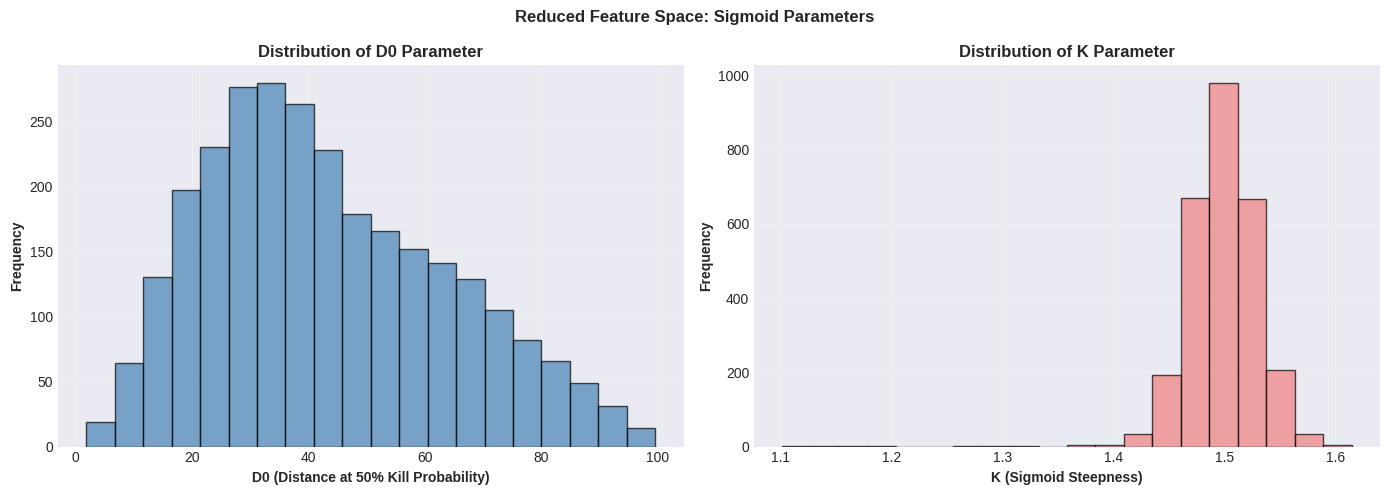


Full Summary:


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,D0,K
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1.250000,1.250000,20.000000,20.000000,1.500000,43.200885,1.498416
std,0.559117,0.559117,14.144662,14.144662,1.000179,20.599332,0.032807
min,0.500000,0.500000,0.000000,0.000000,0.000000,1.869842,1.102048
25%,0.875000,0.875000,10.000000,10.000000,0.500000,27.357377,1.480296
50%,1.250000,1.250000,20.000000,20.000000,1.500000,39.842304,1.499307
75%,1.625000,1.625000,30.000000,30.000000,2.500000,57.742732,1.518190
max,2.000000,2.000000,40.000000,40.000000,3.000000,99.586389,1.614540


In [92]:
# Statistical Summary of Reduced Features
print("\nStatistical Summary of D0 and K Parameters:")
print(df_final[["D0", "K"]].describe())

# Visualize D0 and K distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_final["D0"], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('D0 (Distance at 50% Kill Probability)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of D0 Parameter', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_final["K"], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('K (Sigmoid Steepness)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of K Parameter', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Reduced Feature Space: Sigmoid Parameters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFull Summary:")
df_final.describe()

In [93]:
# Prepare Reduced Dataset for Second-Level Modeling
print("\n" + "="*70)
print("SECOND-LEVEL REGRESSION: Modeling D0 Parameter")
print("="*70)

y_d0 = df_final["D0"]  # Target: D0 parameter
x_reduced = df_final.drop(["D0", "K"], axis=1)  # Features: control parameters

print(f"\nTarget variable (D0): mean={y_d0.mean():.3f}, std={y_d0.std():.3f}")
print(f"Feature set: {x_reduced.columns.tolist()}")

# Split reduced dataset
X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    x_reduced, y_d0, test_size=0.25, random_state=42
)

print(f"\nReduced training set: {X_train_r2.shape[0]} samples")
print(f"Reduced test set: {X_test_r2.shape[0]} samples")

print("\n**Note:** This reduced feature space (D0 as target) can now be modeled using the same")
print("regression techniques to predict the 50% kill probability distance based on control parameters.")


SECOND-LEVEL REGRESSION: Modeling D0 Parameter

Target variable (D0): mean=43.201, std=20.599
Feature set: ['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA']

Reduced training set: 2100 samples
Reduced test set: 700 samples

**Note:** This reduced feature space (D0 as target) can now be modeled using the same
regression techniques to predict the 50% kill probability distance based on control parameters.
